<a href="https://colab.research.google.com/github/Vinayakra/content-creation-assistant/blob/main/telecom%20eda%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("telco_data.csv")
df.head(10)

,customerID,gender,PhoneService,InternetService,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,DSL,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,Yes,DSL,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,Yes,DSL,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,DSL,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,Yes,Fiber optic,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,Yes,Fiber optic,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,Yes,Fiber optic,Yes,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,No,DSL,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,Yes,Fiber optic,NaN,Month-to-month,Yes,Electronic check,NaN,3046.05,Yes
9,6388-TABGU,Male,Yes,DSL,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
print(df.columns)

Index(['customerID', 'gender', 'PhoneService', 'InternetService',
       'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
df.columns=df.columns.str.strip().str.lower()
print(df.columns)

Index(['customerid', 'gender', 'phoneservice', 'internetservice',
       'streamingtv', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   phoneservice      7043 non-null   object 
 3   internetservice   6043 non-null   object 
 4   streamingtv       5543 non-null   object 
 5   contract          7043 non-null   object 
 6   paperlessbilling  7043 non-null   object 
 7   paymentmethod     7043 non-null   object 
 8   monthlycharges    5543 non-null   float64
 9   totalcharges      7043 non-null   object 
 10  churn             7043 non-null   object 
dtypes: float64(1), object(10)
memory usage: 605.4+ KB
None


In [ ]:
# fixing data types
df['monthlycharges'] = pd.to_numeric(df['monthlycharges'], errors='coerce')
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   phoneservice      7043 non-null   object 
 3   internetservice   6043 non-null   object 
 4   streamingtv       5543 non-null   object 
 5   contract          7043 non-null   object 
 6   paperlessbilling  7043 non-null   object 
 7   paymentmethod     7043 non-null   object 
 8   monthlycharges    5543 non-null   float64
 9   totalcharges      7032 non-null   float64
 10  churn             7043 non-null   object 
dtypes: float64(2), object(9)
memory usage: 605.4+ KB
None


In [ ]:
print(df.isnull().sum())

customerid             0
gender               750
phoneservice           0
internetservice     1000
streamingtv         1500
contract               0
paperlessbilling       0
paymentmethod          0
monthlycharges      1500
totalcharges          11
churn                  0
dtype: int64


In [ ]:
#filling null values

df['gender'] = df['gender'].fillna('Other')
df['internetservice'] = df['internetservice'].fillna('No')
df['streamingtv'] = df['streamingtv'].fillna('No')

df['totalcharges']=df['totalcharges'].fillna(df['totalcharges'].median())
df['monthlycharges']=df['monthlycharges'].fillna(df['monthlycharges'].median())

In [ ]:
print(df.isnull().sum())

customerid          0
gender              0
phoneservice        0
internetservice     0
streamingtv         0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [ ]:
print(df.describe())

       monthlycharges  totalcharges
count     7043.000000   7043.000000
mean        66.084751   2281.916928
std         26.804520   2265.270398
min         18.250000     18.800000
25%         49.450000    402.225000
50%         70.550000   1397.475000
75%         84.850000   3786.600000
max        118.600000   8684.800000


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/tmp/ipykernel_5031/2687731485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df,palette='coolwarm')


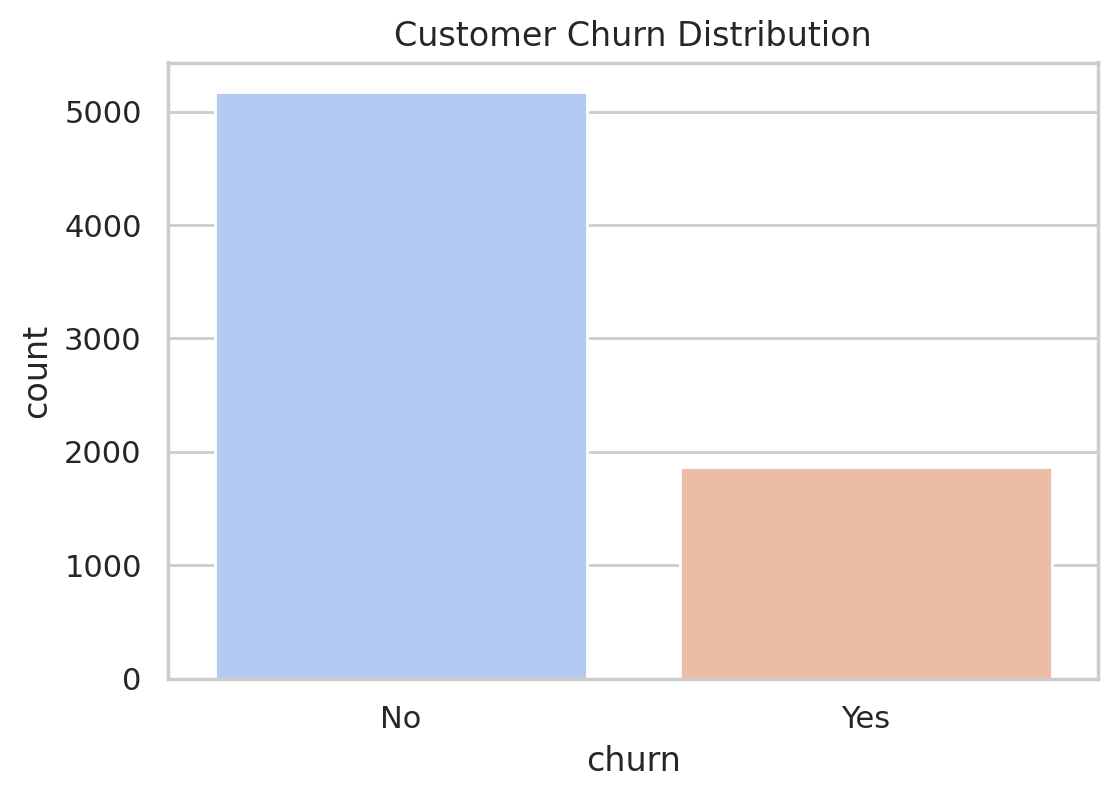

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df,palette='coolwarm')
plt.title('Customer Churn Distribution')
plt.show()

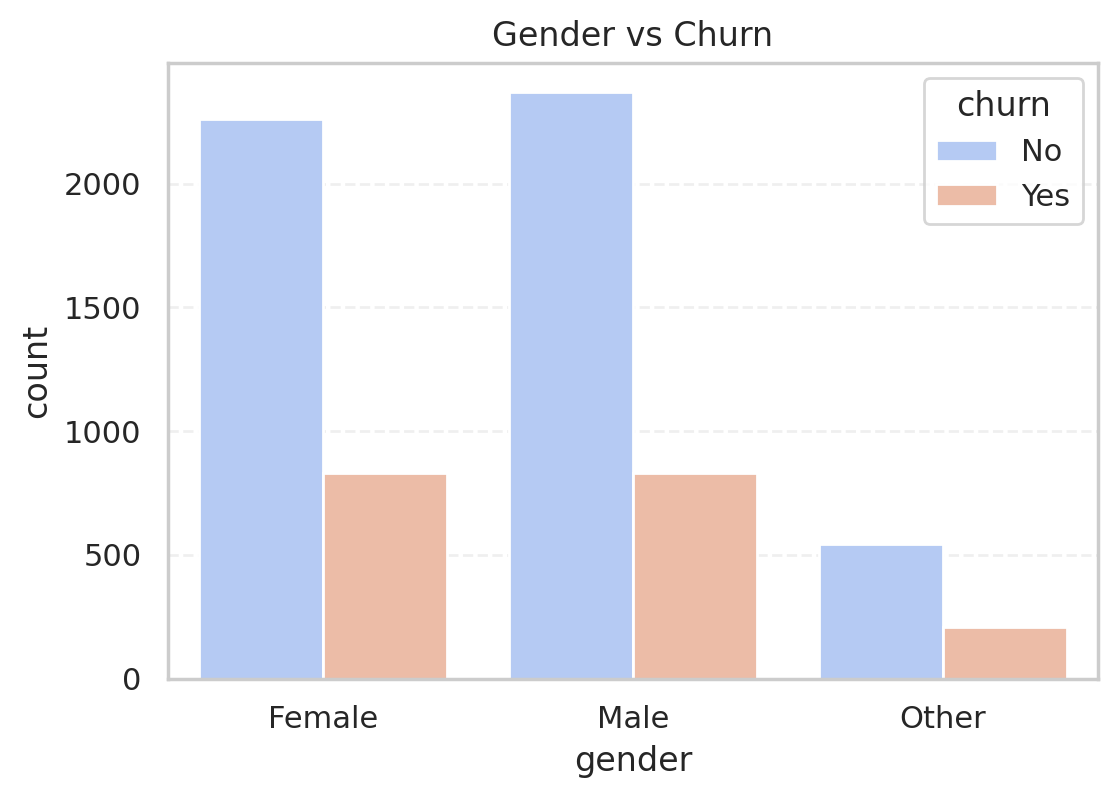

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='churn', data=df, palette='coolwarm',edgecolor='white')
plt.title('Gender vs Churn')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()

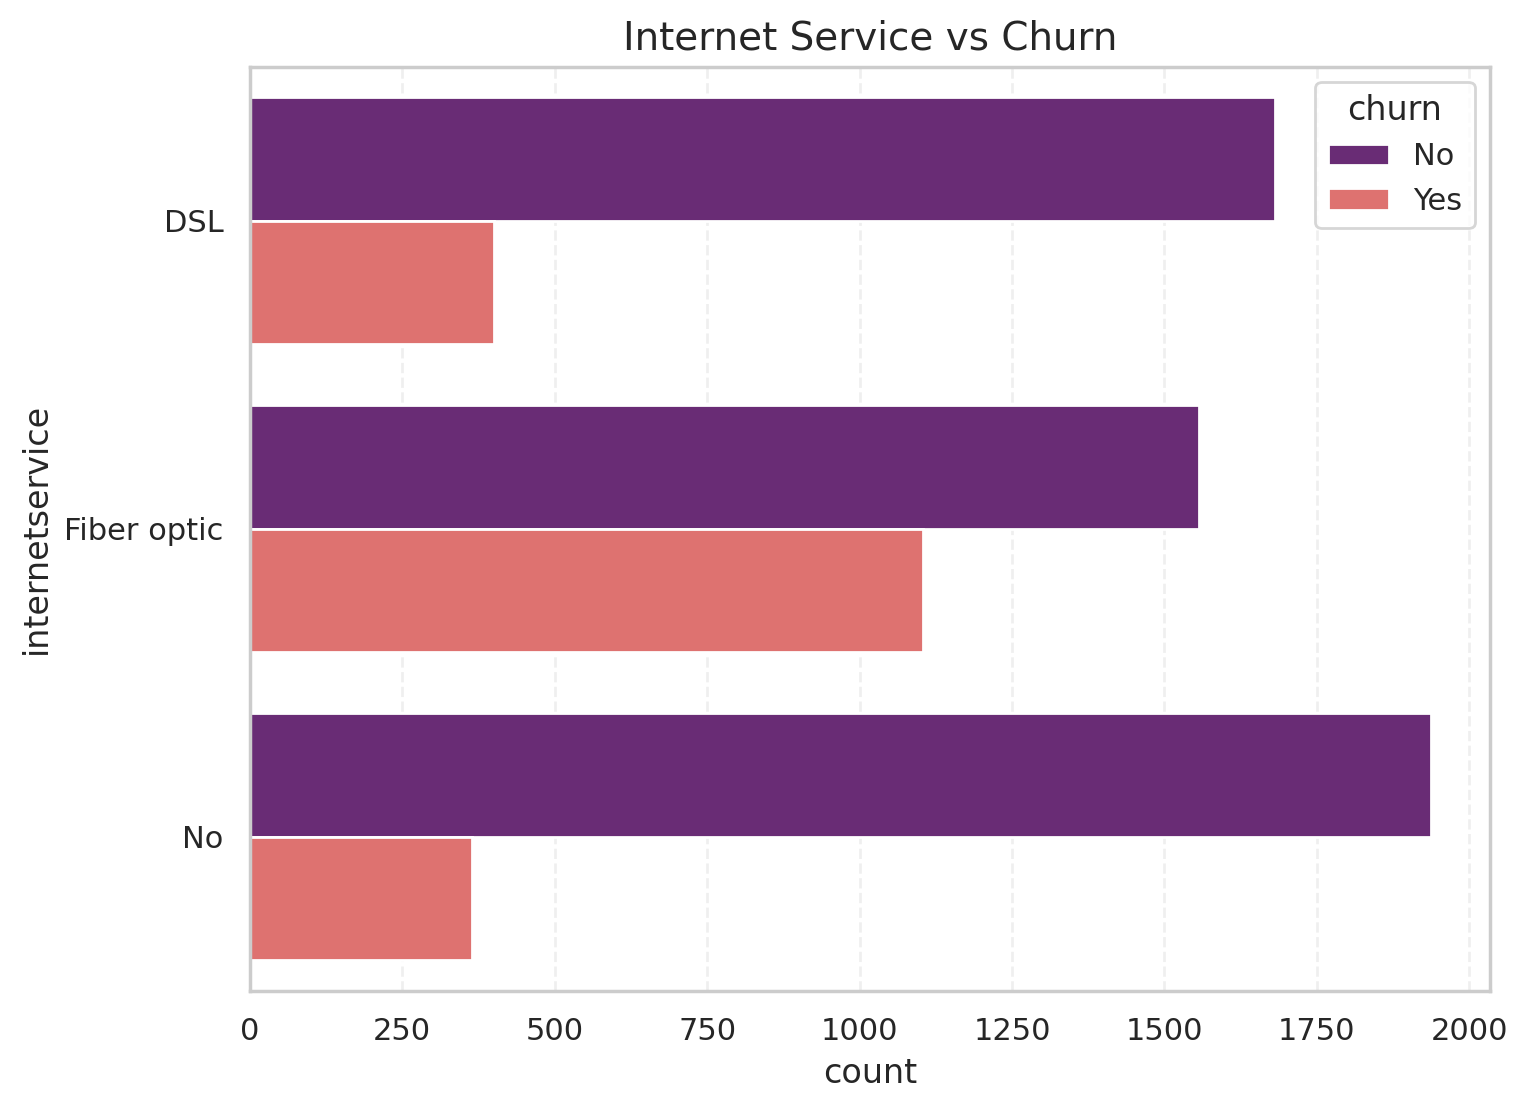

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(y='internetservice',hue='churn',data=df,palette='magma',edgecolor='white')
plt.title('Internet Service vs Churn', fontsize=14,)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.show()

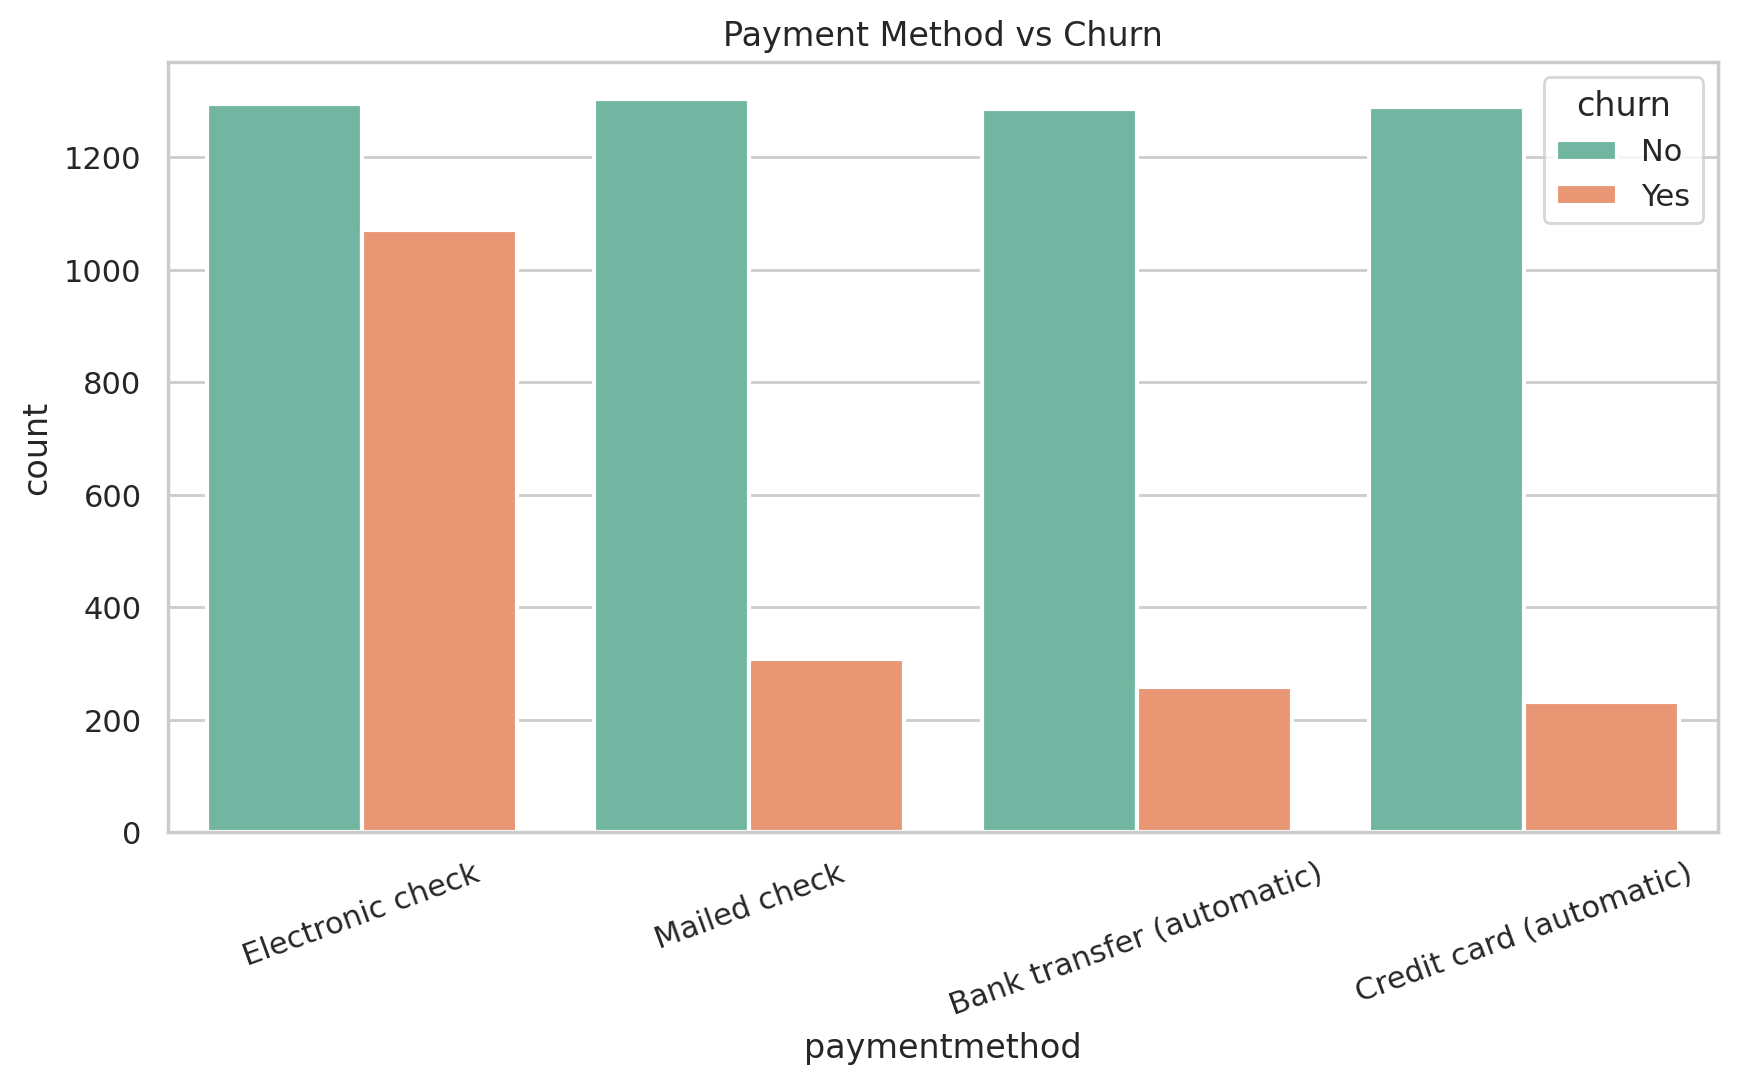

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='paymentmethod', hue='churn', data=df,palette='Set2', edgecolor='white', linewidth=1.5)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=20)
plt.show()

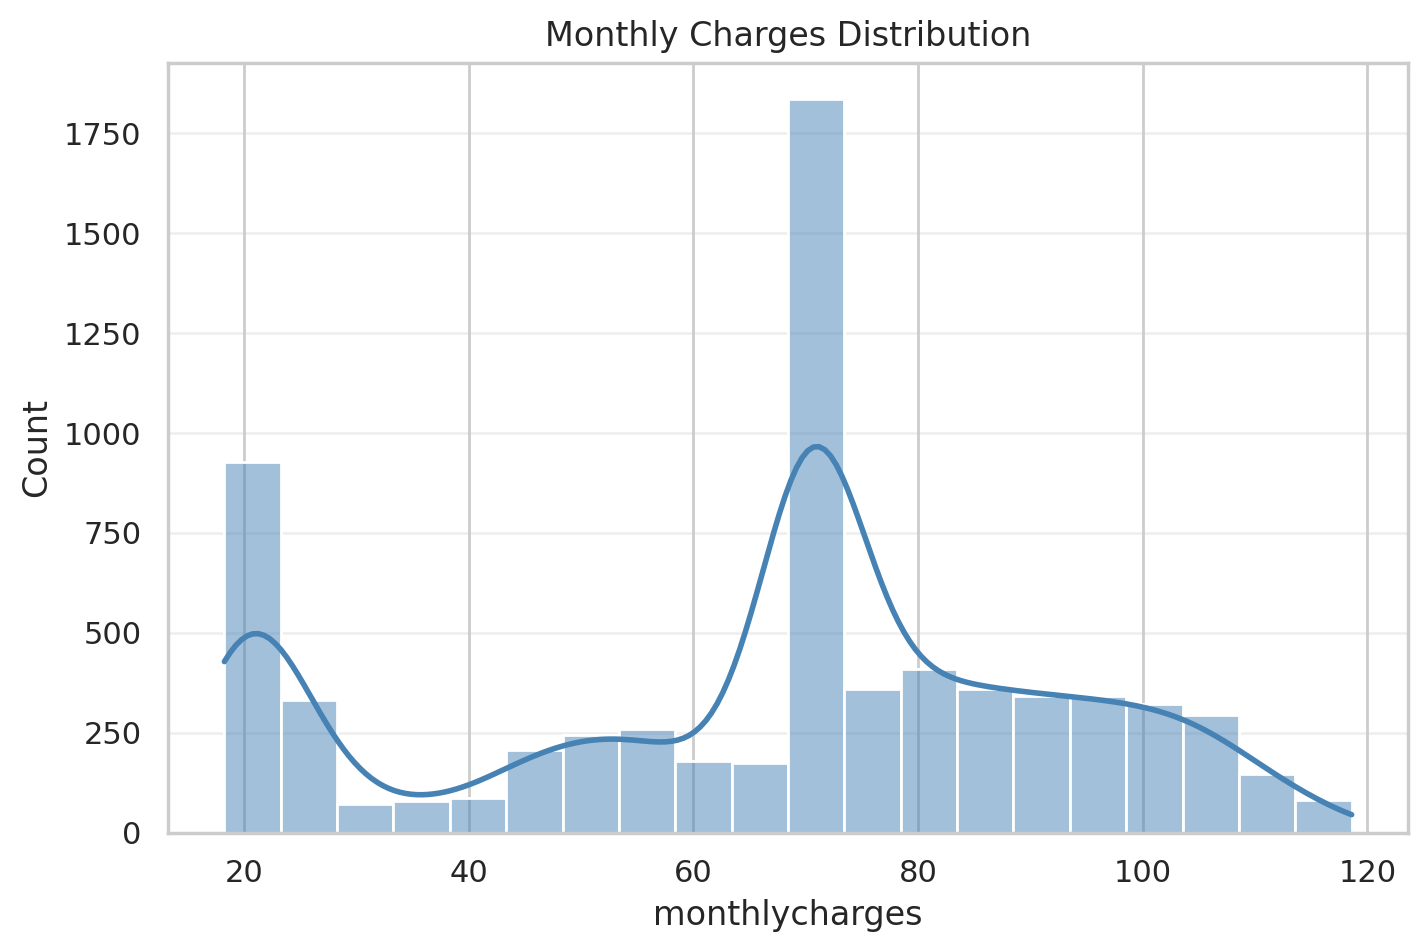

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['monthlycharges'], bins=20, kde=True, color='steelblue', edgecolor='white', line_kws={'linewidth': 2})
plt.title('Monthly Charges Distribution')
plt.grid(axis='y', alpha=0.3)
plt.show()


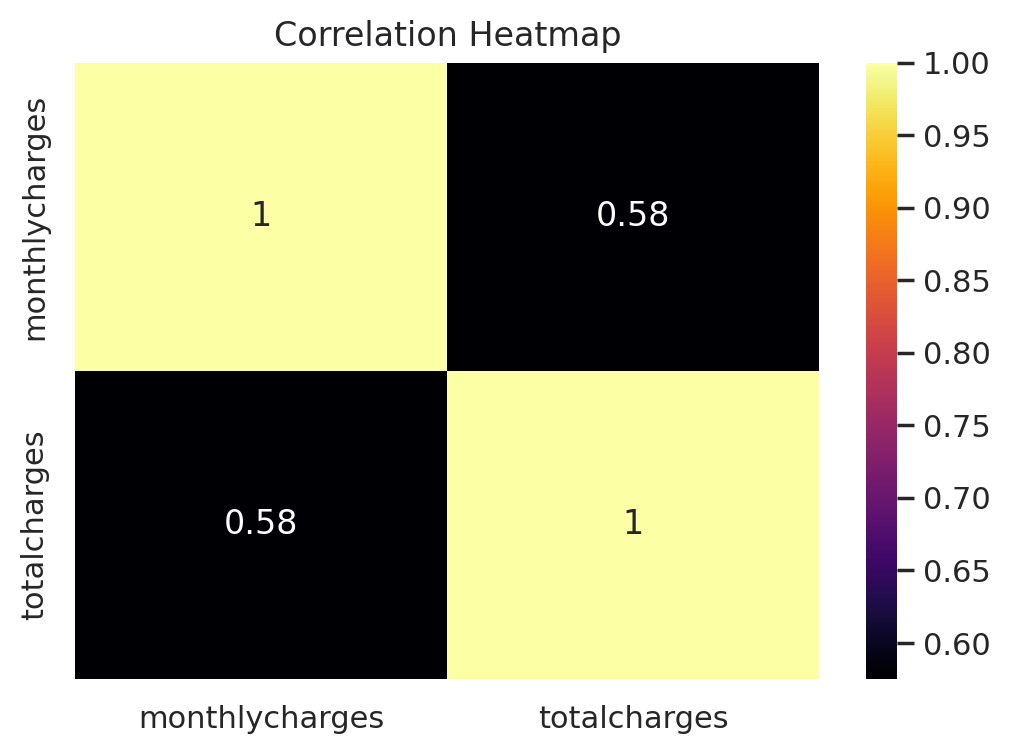

In [ ]:
num_df = df[['monthlycharges', 'totalcharges']]

# matrix
cor = num_df.corr()

# heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cor, annot=True, cmap='inferno')
plt.title('Correlation Heatmap')
plt.show()

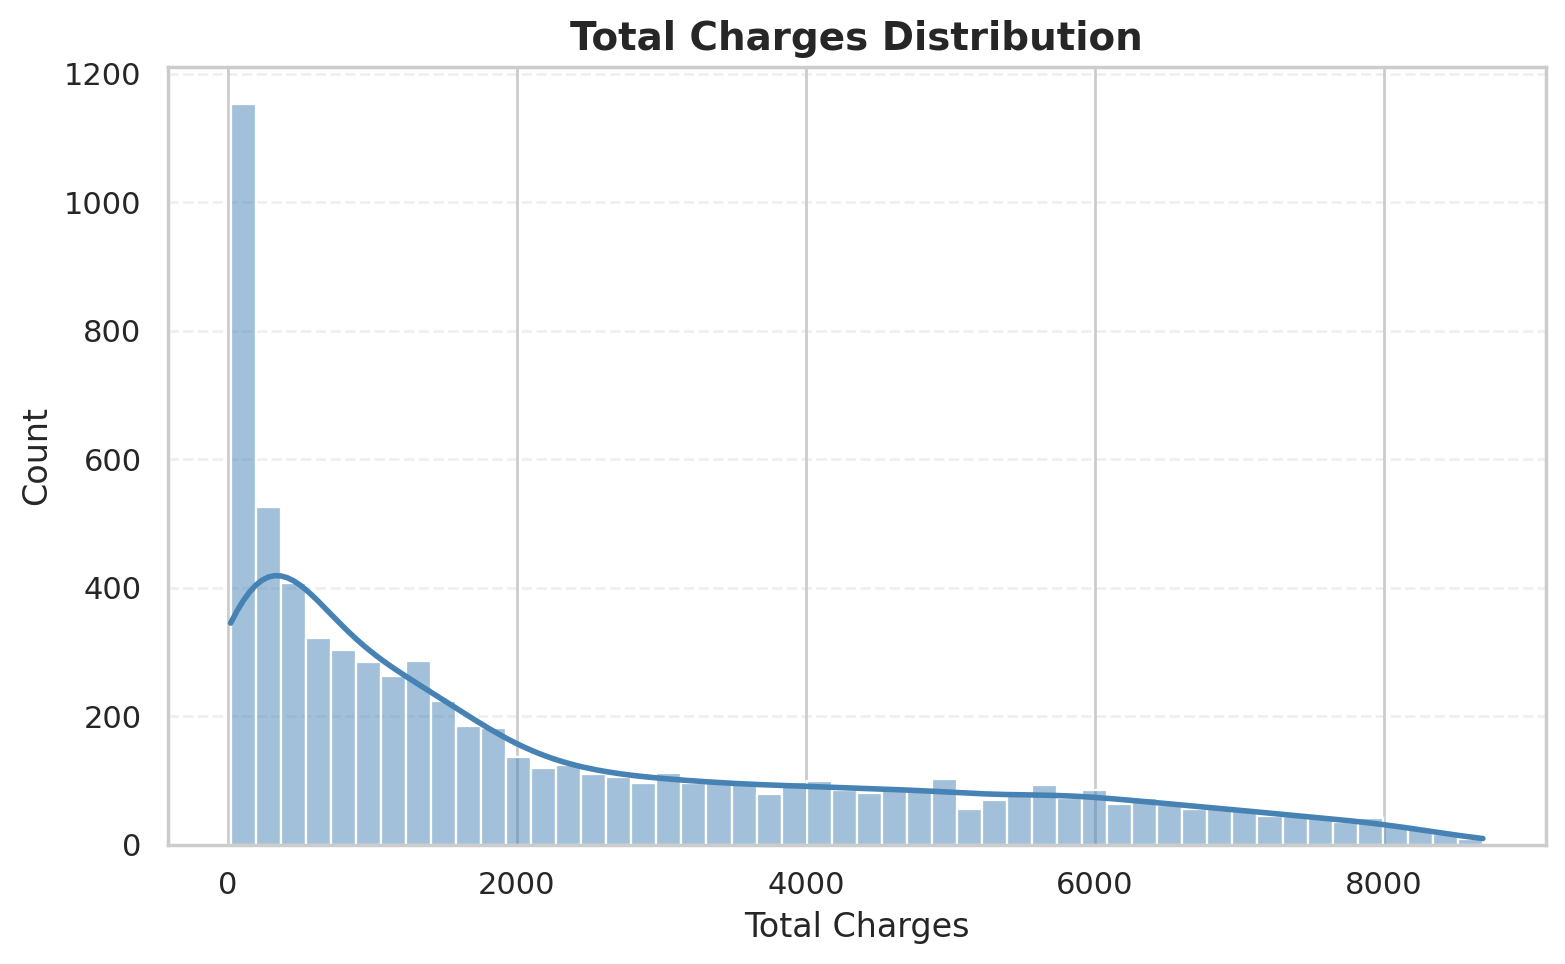

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['totalcharges'],
    bins=50,
    kde=True,
    color='steelblue',
    edgecolor='white',
    line_kws={'linewidth': 2}
)

plt.title('Total Charges Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Total Charges')
plt.grid(axis='y',alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
churn_percent = df['churn'].value_counts(normalize=True) * 100
print(churn_percent)

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
df.to_csv('cleaned_telco_data.csv', index=False)